# Plot feature overlap between Efavirenz correlates and HEU/HUU differences

In [8]:
import matplotlib.pylab as plt
import pandas as pd

cor_file = "supplementary_data/2026-08-25_RP_neg_Cord_efavirenz_correlations.tsv"
diff_file = "supplementary_data/2026-08-25_RP_neg_Cord_sig_diff_features.tsv"

In [9]:
corlist = pd.read_csv(cor_file, sep='\t')
corlist = corlist.sort_values(by="pvalue_adjusted")

difflist = pd.read_csv(diff_file, sep='\t')
difflist = difflist.sort_values(by="pvalue_adjusted")

difflist.head()

,feature_id,statistic,pvalue,pvalue_adjusted,log2fc,origin,mode,mz,rtime
1490,F39143,-21.711722,1.648486e-47,3.808002e-44,3.607797,Cord,RP_neg,381.9770,36.67
1512,F39579,-22.011957,1.809045e-46,2.089447e-43,3.090042,Cord,RP_neg,383.9737,36.67
1500,F39259,-21.761955,1.375334e-45,1.059007e-42,2.748289,Cord,RP_neg,382.9804,36.80
1489,F39142,-20.739954,3.023081e-45,1.452332e-42,4.660242,Cord,RP_neg,381.9770,33.39
1514,F39591,-20.150082,3.143576e-45,1.452332e-42,5.029275,Cord,RP_neg,383.9927,31.42


In [10]:
corlist = corlist['feature_id'].to_list()
difflist = difflist['feature_id'].to_list()
difflist[:5]

['F39143', 'F39579', 'F39259', 'F39142', 'F39591']

0
48
88
104
122
138
165


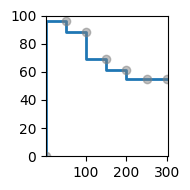

In [28]:
ranges = [1, 50, 100, 150, 200, 250, 300]
overlap_numbers = []
overlap_perc = []
for ii in ranges:
    overlap = len(set(corlist[:ii]).intersection(set(difflist[:ii])))
    print(overlap)
    overlap_numbers.append(overlap)
    overlap_perc.append(100*overlap/ii)
    
plt.figure(figsize=(2,2))
plt.step(ranges, overlap_perc, linewidth=2)
plt.plot(ranges, overlap_perc, 'o', color='grey', alpha=0.5)
plt.xlim(2, 302)
plt.ylim([0, 100])
plt.tight_layout()
plt.savefig("Fig2g_overlap_stepplot.pdf", dpi=300)

# Summary

Added as insert to Fig. 2f.